In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import librosa
import librosa.display
import numpy as np
from pathlib import Path
import shutil

In [ ]:
!pip install kaggle --quiet

import os
from pathlib import Path
import pandas as pd
import shutil
import matplotlib.pyplot as plt

!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

!kaggle datasets download -d ejlok1/toronto-emotional-speech-set-tess -p ./data_tess --unzip
!kaggle datasets download -d barelydedicated/savee-database -p ./data_savee --unzip


Dataset URL: https://www.kaggle.com/datasets/ejlok1/toronto-emotional-speech-set-tess
License(s): Attribution-NonCommercial-NoDerivatives 4.0 International (CC BY-NC-ND 4.0)
 93% 396M/428M [00:00<00:00, 445MB/s]
100% 428M/428M [00:00<00:00, 475MB/s]
Dataset URL: https://www.kaggle.com/datasets/barelydedicated/savee-database
License(s): copyright-authors
 95% 205M/215M [00:01<00:00, 170MB/s]
100% 215M/215M [00:01<00:00, 156MB/s]


✅ Собрано 3760 файлов


,file_path,emotion,speaker,dataset
0,audio/tess_OAF_neutral_OAF_merge_neutral.wav,neutral,OAF,TESS
1,audio/tess_OAF_neutral_OAF_youth_neutral.wav,neutral,OAF,TESS
2,audio/tess_OAF_neutral_OAF_puff_neutral.wav,neutral,OAF,TESS
3,audio/tess_OAF_neutral_OAF_cause_neutral.wav,neutral,OAF,TESS
4,audio/tess_OAF_neutral_OAF_red_neutral.wav,neutral,OAF,TESS


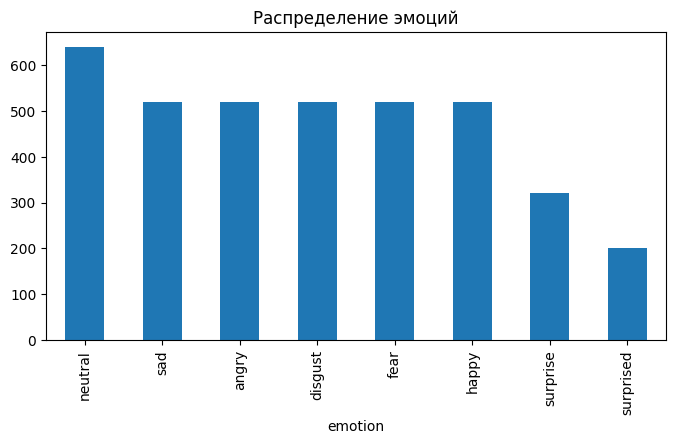

In [ ]:
from pathlib import Path
import pandas as pd
import shutil
import matplotlib.pyplot as plt


out_dir = Path("combined_dataset")
audio_dir = out_dir / "audio"
audio_dir.mkdir(parents=True, exist_ok=True)
rows = []

tess_root = Path("data_tess") / "TESS Toronto emotional speech set data"
audio_dir = Path("combined_dataset/audio")
audio_dir.mkdir(parents=True, exist_ok=True)

for emo_dir in tess_root.iterdir():
    if emo_dir.is_dir():
        emotion = emo_dir.name.lower().split("_")[-1]
        for wav in emo_dir.glob("*.wav"):
            speaker = "OAF" if "OAF" in wav.name else "YAF"
            new_name = f"tess_{speaker}_{emotion}_{wav.name}"
            shutil.copy(wav, audio_dir / new_name)
            rows.append({
                "file_path": f"audio/{new_name}",
                "emotion": emotion,
                "speaker": speaker,
                "dataset": "TESS"
            })

savee_root = Path("data_savee")

emotion_map = {
    "a": "angry",
    "d": "disgust",
    "f": "fear",
    "h": "happy",
    "n": "neutral",
    "sa": "sad",
    "su": "surprise"
}

for wav in savee_root.rglob("*.wav"):
    stem = wav.stem.lower()
    speaker = stem.split("_")[0]

    emotion = None
    for code, emo in emotion_map.items():
        if f"_{code}" in stem or stem.startswith(code):
            emotion = emo
            break
    if emotion is None:
        emotion = "unknown"

    new_name = f"savee_{speaker}_{emotion}_{wav.name}"
    shutil.copy(wav, audio_dir / new_name)

    rows.append({
        "file_path": f"audio/{new_name}",
        "emotion": emotion,
        "dataset": "SAVEE",
        "speaker": speaker
    })


df = pd.DataFrame(rows)
df.to_csv(out_dir / "metadata.csv", index=False)

print(f"✅ Собрано {len(df)} файлов")
display(df.head())


if len(df) > 0:
    df["emotion"].value_counts().plot(kind="bar", figsize=(8,4), title="Распределение эмоций")
    plt.show()
else:
    print("⚠️ Нет найденых файлов .wav — проверьте пути в data_tess/ и data_savee/")


EDA

In [ ]:
df.dataset.value_counts()

,count
dataset,
TESS,2800
SAVEE,960


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3760 entries, 0 to 3759
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   file_path  3760 non-null   object
 1   emotion    3760 non-null   object
 2   speaker    3760 non-null   object
 3   dataset    3760 non-null   object
dtypes: object(4)
memory usage: 117.6+ KB


In [ ]:
# Количество эмоций
print(df['emotion'].value_counts())

# Количество данных для каждого датасета
print(df['dataset'].value_counts())

# Количество файлов на спикера
print(df['speaker'].value_counts())


emotion
neutral      640
sad          520
angry        520
disgust      520
fear         520
happy        520
surprise     320
surprised    200
Name: count, dtype: int64
dataset
TESS     2800
SAVEE     960
Name: count, dtype: int64
speaker
YAF     1401
OAF     1399
n22        8
f10        8
d13        8
        ... 
n08        8
sa07       8
n02        8
h15        8
a04        8
Name: count, Length: 122, dtype: int64


Визуализация распределения эмоций

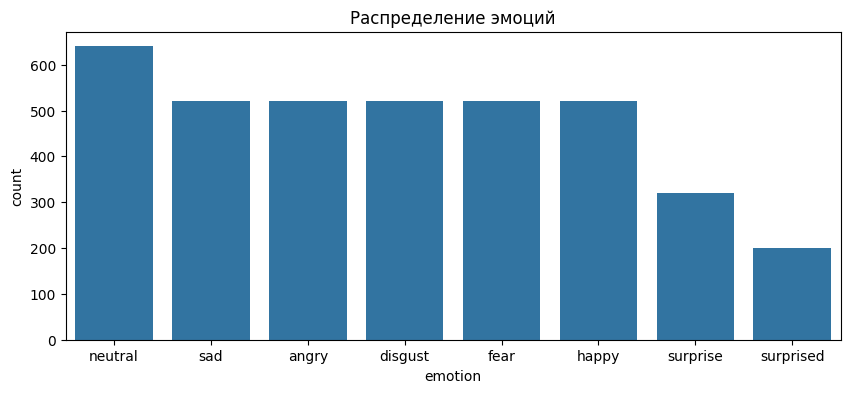

In [ ]:
plt.figure(figsize=(10,4))
sns.countplot(x='emotion', data=df, order=df['emotion'].value_counts().index)
plt.title("Распределение эмоций")
plt.show()

In [ ]:
df_emon = df['emotion'].value_counts()
df_emon

,count
emotion,
neutral,640
sad,520
angry,520
disgust,520
fear,520
happy,520
surprise,320
surprised,200


In [ ]:
df['emotion'] = df['emotion'].replace({'surprised': 'surprise'})
print(df['emotion'].value_counts())

emotion
neutral     640
sad         520
angry       520
surprise    520
disgust     520
happy       520
fear        520
Name: count, dtype: int64


In [ ]:
df_emon = df['emotion'].value_counts()
df_emon

,count
emotion,
neutral,640
sad,520
angry,520
surprise,520
disgust,520
happy,520
fear,520


Длительности аудио

In [ ]:
df.file_path

,file_path
0,audio/tess_OAF_neutral_OAF_merge_neutral.wav
1,audio/tess_OAF_neutral_OAF_youth_neutral.wav
2,audio/tess_OAF_neutral_OAF_puff_neutral.wav
3,audio/tess_OAF_neutral_OAF_cause_neutral.wav
4,audio/tess_OAF_neutral_OAF_red_neutral.wav
...,...
3755,audio/savee_n08_neutral_n08.wav
3756,audio/savee_sa07_sad_sa07.wav
3757,audio/savee_n02_neutral_n02.wav
3758,audio/savee_h15_happy_h15.wav


count    3760.000000
mean        2.556146
std         1.036880
min         1.254076
25%         1.920056
50%         2.193905
75%         2.688990
max         7.012585
Name: duration, dtype: float64


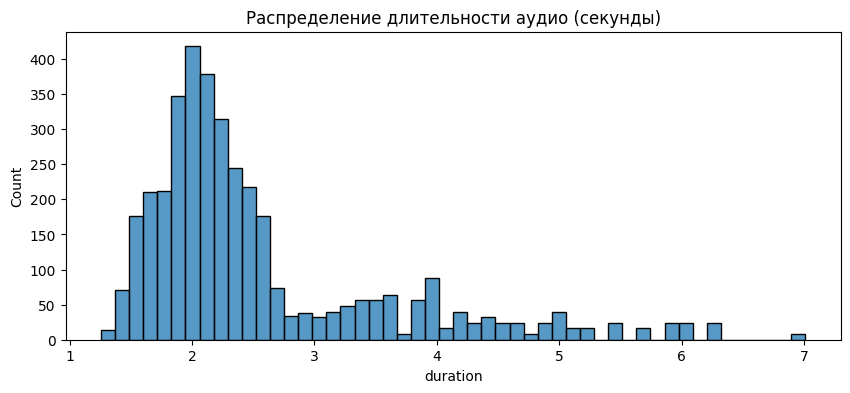

In [ ]:
durations = []
for f in df['file_path']:
    path = audio_dir / Path(f).name
    y, sr = librosa.load(path, sr=None)
    durations.append(len(y)/sr)

df['duration'] = durations


print(df['duration'].describe())

plt.figure(figsize=(10,4))
sns.histplot(df['duration'], bins=50)
plt.title("Распределение длительности аудио (секунды)")
plt.show()


Пример мел-спектрограммы

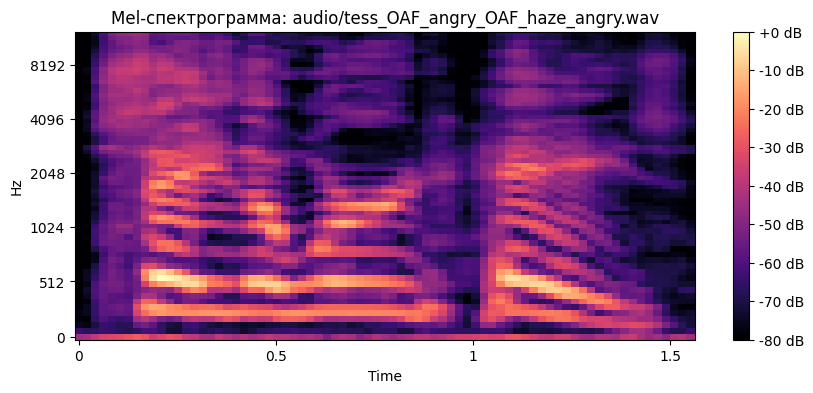

In [ ]:
import librosa
import librosa.display
import matplotlib.pyplot as plt

# загружаем аудио
sample_file = df[df['emotion']=='angry'].sample(1)['file_path'].values[0]
y, sr = librosa.load(audio_dir / Path(sample_file).name, sr=None)

# мел-спектрограмма
S = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=64)
S_dB = librosa.power_to_db(S, ref=np.max)

plt.figure(figsize=(10, 4))
librosa.display.specshow(S_dB, sr=sr, x_axis='time', y_axis='mel')
plt.colorbar(format='%+2.0f dB')
plt.title(f"Mel-спектрограмма: {sample_file}")
plt.show()

ML часть

In [ ]:
import numpy as np
import pandas as pd
from pathlib import Path
import librosa
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt


In [ ]:
df['emotion'] = df['emotion'].replace({'surprised': 'surprise'})


In [ ]:
audio_dir = Path("combined_dataset/audio")

In [ ]:
def extract_features(file_path, n_mfcc=13):
    y, sr = librosa.load(audio_dir / Path(file_path).name, sr=None)

    # MFCC
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc)
    mfcc_mean = np.mean(mfcc, axis=1)
    mfcc_std = np.std(mfcc, axis=1)

    # Delta MFCC
    mfcc_delta = librosa.feature.delta(mfcc)
    mfcc_delta_mean = np.mean(mfcc_delta, axis=1)

    # Объединяем все признаки в один вектор
    features = np.concatenate([mfcc_mean, mfcc_std, mfcc_delta_mean])
    return features


X = np.array([extract_features(f) for f in df['file_path']])
y = df['emotion'].values


from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y_encoded = le.fit_transform(y)


In [ ]:
from sklearn.model_selection import train_test_split
import numpy as np

# 1. Сначала разделяем ДАННЫЕ (до извлечения признаков!)
train_df, test_df = train_test_split(
    df,
    test_size=0.2,
    stratify=df['emotion'],
    random_state=42
)

print(f"Train: {len(train_df)}, Test: {len(test_df)}")

# 2. Извлекаем признаки ОТДЕЛЬНО
def extract_features_safe(file_list):
    return np.array([extract_features(f) for f in file_list])

X_train = extract_features_safe(train_df['file_path'])
X_test = extract_features_safe(test_df['file_path'])

y_train = train_df['emotion'].values
y_test = test_df['emotion'].values

# 3. Кодируем метки
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)  # Только transform для test!

# 4. Масштабируем ОТДЕЛЬНО
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("✅ Данные подготовлены без утечек!")

Train: 3008, Test: 752
✅ Данные подготовлены без утечек!


In [ ]:
# Обучаем на исправленных данных
rf = RandomForestClassifier(n_estimators=10, max_depth=5, random_state=42)
rf.fit(X_train_scaled, y_train_encoded)
y_pred_rf = rf.predict(X_test_scaled)

print("=== RandomForest (БЕЗ УТЕЧЕК) ===")
print(classification_report(y_test_encoded, y_pred_rf, target_names=le.classes_))

=== RandomForest (БЕЗ УТЕЧЕК) ===
              precision    recall  f1-score   support

       angry       0.67      0.88      0.76       104
     disgust       0.88      0.84      0.86       104
        fear       0.88      0.77      0.82       104
       happy       0.88      0.83      0.85       104
     neutral       0.80      0.89      0.84       128
         sad       0.83      0.82      0.83       104
    surprise       0.90      0.71      0.80       104

    accuracy                           0.82       752
   macro avg       0.83      0.82      0.82       752
weighted avg       0.83      0.82      0.82       752



In [ ]:
svm = SVC(kernel='rbf', C=10, gamma='scale', random_state=42)
svm.fit(X_train_scaled, y_train_encoded)
y_pred_svm = svm.predict(X_test_scaled)

print(classification_report(y_test_encoded, y_pred_svm, target_names=le.classes_))

              precision    recall  f1-score   support

       angry       0.99      1.00      1.00       104
     disgust       0.98      0.99      0.99       104
        fear       1.00      0.99      1.00       104
       happy       1.00      0.98      0.99       104
     neutral       1.00      0.99      1.00       128
         sad       0.99      1.00      1.00       104
    surprise       0.97      0.98      0.98       104

    accuracy                           0.99       752
   macro avg       0.99      0.99      0.99       752
weighted avg       0.99      0.99      0.99       752



In [ ]:
lr = LogisticRegression(max_iter=10000, multi_class='multinomial', random_state=42)
lr.fit(X_train_scaled, y_train_encoded)
y_pred_lr = lr.predict(X_test_scaled)

print("=== Logistic Regression ===")
print(classification_report(y_test_encoded, y_pred_lr, target_names=le.classes_))


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


=== Logistic Regression ===
              precision    recall  f1-score   support

       angry       0.82      0.86      0.84       104
     disgust       0.97      0.89      0.93       104
        fear       0.93      0.90      0.92       104
       happy       0.83      0.83      0.83       104
     neutral       0.84      0.96      0.90       128
         sad       0.95      0.83      0.88       104
    surprise       0.80      0.83      0.82       104

    accuracy                           0.87       752
   macro avg       0.88      0.87      0.87       752
weighted avg       0.88      0.87      0.87       752



Нейронки

In [ ]:
from tensorflow.keras.utils import to_categorical
import tensorflow as tf
print("GPU is", "available" if tf.config.list_physical_devices('GPU') else "NOT AVAILABLE")


GPU is NOT AVAILABLE


In [ ]:
from tensorflow.keras.utils import to_categorical
# Кодируем метки
le = LabelEncoder()
y_encoded = le.fit_transform(df['emotion'])
y_onehot = to_categorical(y_encoded)

# Функция извлечения MFCC фиксированной длины
def extract_mfcc_fixed(file_path, n_mfcc=40, max_len=200):
    y, sr = librosa.load(audio_dir / Path(file_path).name, sr=None)
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc)
    # Транспонируем: (n_mfcc, time) -> (time, n_mfcc)
    mfcc = mfcc.T
    if mfcc.shape[0] < max_len:
        pad_width = max_len - mfcc.shape[0]
        mfcc = np.pad(mfcc, ((0,pad_width),(0,0)), mode='constant')
    else:
        mfcc = mfcc[:max_len, :]
    return mfcc

X = np.array([extract_mfcc_fixed(f) for f in df['file_path']])
y = y_onehot

print("X shape:", X.shape)  # (num_samples, time_steps, n_mfcc)
print("y shape:", y.shape)  # (num_samples, num_classes)

X shape: (6560, 200, 40)
y shape: (6560, 7)


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Dropout, LSTM, Dense, BatchNormalization
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau
# Разделяем данные для нейросети
X_train, X_test, y_train, y_test = train_test_split(
    X, y_onehot, test_size=0.2, stratify=y_encoded, random_state=42
)

print(f"X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"X_test: {X_test.shape}, y_test: {y_test.shape}")
n_classes = y.shape[1]
# Создаем модель
model = Sequential([
    BatchNormalization(input_shape=X_train.shape[1:]),

    Conv1D(128, kernel_size=2, activation='relu'),
    MaxPooling1D(pool_size=2),
    Dropout(0.35),

    Conv1D(256, kernel_size=2, activation='relu'),
    MaxPooling1D(pool_size=2),
    Dropout(0.3),

    Conv1D(128, kernel_size=3, activation='relu'),
    MaxPooling1D(pool_size=2),
    Dropout(0.3),

    Conv1D(64, kernel_size=2, activation='relu'),
    MaxPooling1D(pool_size=2),
    Dropout(0.3),

    LSTM(128, return_sequences=True),
    LSTM(128),

    Dense(n_classes, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

# Callbacks
checkpoint = ModelCheckpoint('emotion_lstm_best_model.h5',
                           monitor='val_accuracy',
                           save_best_only=True,
                           mode='max')

reduce_lr = ReduceLROnPlateau(monitor='loss', factor=0.4,
                            patience=2, min_lr=1e-4)

# Обучение
print("🎯 Обучаем нейросеть...")
history = model.fit(
    X_train, y_train,
    batch_size=128,
    epochs=25,
    validation_data=(X_test, y_test),
    callbacks=[checkpoint, reduce_lr],
    verbose=1
)

X_train: (5248, 200, 40), y_train: (5248, 7)
X_test: (1312, 200, 40), y_test: (1312, 7)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/normalization/batch_normalization.py:142: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ batch_normalization_1           │ (None, 200, 40)        │           160 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_4 (Conv1D)               │ (None, 199, 128)       │        10,368 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_4 (MaxPooling1D)  │ (None, 99, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 99, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_5 (Conv1D)               │ (None, 98, 256)        │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_5 (MaxPooling1D)  │ (None, 49, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 49, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_6 (Conv1D)               │ (None, 47, 128)        │        98,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_6 (MaxPooling1D)  │ (None, 23, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 23, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_7 (Conv1D)               │ (None, 22, 64)         │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_7 (MaxPooling1D)  │ (None, 11, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 11, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 11, 128)        │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 128)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 422,503 (1.61 MB)

...

41/41 ━━━━━━━━━━━━━━━━━━━━ 22s 487ms/step - accuracy: 0.9796 - loss: 0.0593 - val_accuracy: 0.9909 - val_loss: 0.0334 - learning_rate: 0.0010
Epoch 9/25
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 416ms/step - accuracy: 0.9906 - loss: 0.0355

41/41 ━━━━━━━━━━━━━━━━━━━━ 18s 451ms/step - accuracy: 0.9906 - loss: 0.0354 - val_accuracy: 0.9924 - val_loss: 0.0326 - learning_rate: 0.0010
Epoch 10/25
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 424ms/step - accuracy: 0.9869 - loss: 0.0372

41/41 ━━━━━━━━━━━━━━━━━━━━ 21s 452ms/step - accuracy: 0.9869 - loss: 0.0372 - val_accuracy: 0.9954 - val_loss: 0.0163 - learning_rate: 0.0010
Epoch 11/25
41/41 ━━━━━━━━━━━━━━━━━━━━ 21s 477ms/step - accuracy: 0.9879 - loss: 0.0366 - val_accuracy: 0.9916 - val_loss: 0.0258 - learning_rate: 0.0010
Epoch 12/25
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 421ms/step - accuracy: 0.9918 - loss: 0.0228

41/41 ━━━━━━━━━━━━━━━━━━━━ 20s 455ms/step - accuracy: 0.9918 - loss: 0.0228 - val_accuracy: 0.9985 - val_loss: 0.0082 - learning_rate: 4.0000e-04
Epoch 13/25
41/41 ━━━━━━━━━━━━━━━━━━━━ 20s 495ms/step - accuracy: 0.9969 - loss: 0.0111 - val_accuracy: 0.9962 - val_loss: 0.0118 - learning_rate: 4.0000e-04
Epoch 14/25
41/41 ━━━━━━━━━━━━━━━━━━━━ 19s 451ms/step - accuracy: 0.9970 - loss: 0.0116 - val_accuracy: 0.9985 - val_loss: 0.0078 - learning_rate: 4.0000e-04
Epoch 15/25
41/41 ━━━━━━━━━━━━━━━━━━━━ 20s 484ms/step - accuracy: 0.9987 - loss: 0.0068 - val_accuracy: 0.9985 - val_loss: 0.0041 - learning_rate: 4.0000e-04
Epoch 16/25
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 415ms/step - accuracy: 0.9966 - loss: 0.0085

41/41 ━━━━━━━━━━━━━━━━━━━━ 18s 443ms/step - accuracy: 0.9966 - loss: 0.0085 - val_accuracy: 1.0000 - val_loss: 0.0028 - learning_rate: 4.0000e-04
Epoch 17/25
41/41 ━━━━━━━━━━━━━━━━━━━━ 19s 473ms/step - accuracy: 0.9976 - loss: 0.0077 - val_accuracy: 0.9985 - val_loss: 0.0083 - learning_rate: 4.0000e-04
Epoch 18/25
41/41 ━━━━━━━━━━━━━━━━━━━━ 18s 441ms/step - accuracy: 0.9993 - loss: 0.0047 - val_accuracy: 0.9985 - val_loss: 0.0068 - learning_rate: 1.6000e-04
Epoch 19/25
41/41 ━━━━━━━━━━━━━━━━━━━━ 19s 461ms/step - accuracy: 0.9986 - loss: 0.0050 - val_accuracy: 0.9985 - val_loss: 0.0072 - learning_rate: 1.6000e-04
Epoch 20/25
41/41 ━━━━━━━━━━━━━━━━━━━━ 20s 439ms/step - accuracy: 0.9984 - loss: 0.0055 - val_accuracy: 0.9985 - val_loss: 0.0084 - learning_rate: 1.6000e-04
Epoch 21/25
41/41 ━━━━━━━━━━━━━━━━━━━━ 19s 467ms/step - accuracy: 0.9977 - loss: 0.0054 - val_accuracy: 0.9985 - val_loss: 0.0068 - learning_rate: 1.0000e-04
Epoch 22/25
41/41 ━━━━━━━━━━━━━━━━━━━━ 18s 440ms/step - accuracy

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y_onehot, test_size=0.2, stratify=y_encoded, random_state=42
)


In [ ]:
model = Sequential([
    BatchNormalization(input_shape=X_train.shape[1:]),
    Conv1D(128, kernel_size=2, activation='relu'),
    MaxPooling1D(pool_size=2),
    Dropout(0.35),

    Conv1D(256, kernel_size=2, activation='relu'),
    MaxPooling1D(pool_size=2),
    Dropout(0.3),

    Conv1D(128, kernel_size=3, activation='relu'),
    MaxPooling1D(pool_size=2),
    Dropout(0.3),

    Conv1D(64, kernel_size=2, activation='relu'),
    MaxPooling1D(pool_size=2),
    Dropout(0.3),

    LSTM(128, return_sequences=True),
    LSTM(128),

    Dense(n_classes, activation='softmax')
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/normalization/batch_normalization.py:142: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ batch_normalization_2           │ (None, 200, 40)        │           160 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_8 (Conv1D)               │ (None, 199, 128)       │        10,368 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_8 (MaxPooling1D)  │ (None, 99, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 99, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_9 (Conv1D)               │ (None, 98, 256)        │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_9 (MaxPooling1D)  │ (None, 49, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 49, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_10 (Conv1D)              │ (None, 47, 128)        │        98,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_10 (MaxPooling1D) │ (None, 23, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 23, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_11 (Conv1D)              │ (None, 22, 64)         │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_11 (MaxPooling1D) │ (None, 11, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 11, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_4 (LSTM)                   │ (None, 11, 128)        │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 128)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 422,503 (1.61 MB)

 Trainable params: 422,423 (1.61 MB)

 Non-trainable params: 80 (320.00 B)

In [ ]:
checkpoint = ModelCheckpoint('cnn_lstm_best_model.h5', monitor='val_accuracy',
                             verbose=1, save_best_only=True, mode='max')

rlrp = ReduceLROnPlateau(monitor='loss', factor=0.4, verbose=1, patience=2, min_lr=1e-4)

n_epochs = 25
history = model.fit(
    X_train, y_train,
    batch_size=128,
    epochs=n_epochs,
    validation_data=(X_test, y_test),
    callbacks=[checkpoint, rlrp]
)


Epoch 1/25
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.4221 - loss: 1.5115
Epoch 1: val_accuracy improved from -inf to 0.75686, saving model to cnn_lstm_best_model.h5


41/41 ━━━━━━━━━━━━━━━━━━━━ 15s 38ms/step - accuracy: 0.4261 - loss: 1.5025 - val_accuracy: 0.7569 - val_loss: 0.7288 - learning_rate: 0.0010
Epoch 2/25
40/41 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.7907 - loss: 0.5521
Epoch 2: val_accuracy improved from 0.75686 to 0.89863, saving model to cnn_lstm_best_model.h5


41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.7920 - loss: 0.5485 - val_accuracy: 0.8986 - val_loss: 0.2713 - learning_rate: 0.0010
Epoch 3/25
39/41 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.8899 - loss: 0.2919
Epoch 3: val_accuracy improved from 0.89863 to 0.92302, saving model to cnn_lstm_best_model.h5


41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.8905 - loss: 0.2903 - val_accuracy: 0.9230 - val_loss: 0.1867 - learning_rate: 0.0010
Epoch 4/25
38/41 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.9242 - loss: 0.2175
Epoch 4: val_accuracy did not improve from 0.92302
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.9233 - loss: 0.2195 - val_accuracy: 0.9192 - val_loss: 0.2002 - learning_rate: 0.0010
Epoch 5/25
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.9078 - loss: 0.2517
Epoch 5: val_accuracy improved from 0.92302 to 0.96570, saving model to cnn_lstm_best_model.h5


41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.9080 - loss: 0.2510 - val_accuracy: 0.9657 - val_loss: 0.1061 - learning_rate: 0.0010
Epoch 6/25
39/41 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.9459 - loss: 0.1498
Epoch 6: val_accuracy did not improve from 0.96570
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.9459 - loss: 0.1502 - val_accuracy: 0.9596 - val_loss: 0.1192 - learning_rate: 0.0010
Epoch 7/25
40/41 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.9482 - loss: 0.1361
Epoch 7: val_accuracy did not improve from 0.96570
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.9481 - loss: 0.1363 - val_accuracy: 0.9619 - val_loss: 0.0944 - learning_rate: 0.0010
Epoch 8/25
39/41 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.9602 - loss: 0.1096
Epoch 8: val_accuracy improved from 0.96570 to 0.97332, saving model to cnn_lstm_best_model.h5


...

41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.9728 - loss: 0.0787 - val_accuracy: 0.9855 - val_loss: 0.0360 - learning_rate: 0.0010
Epoch 12/25
38/41 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.9770 - loss: 0.0800
Epoch 12: val_accuracy improved from 0.98552 to 0.99009, saving model to cnn_lstm_best_model.h5


41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.9771 - loss: 0.0790 - val_accuracy: 0.9901 - val_loss: 0.0376 - learning_rate: 0.0010
Epoch 13/25
40/41 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.9776 - loss: 0.0669
Epoch 13: val_accuracy did not improve from 0.99009
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.9777 - loss: 0.0665 - val_accuracy: 0.9748 - val_loss: 0.0534 - learning_rate: 0.0010
Epoch 14/25
38/41 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.9738 - loss: 0.0714
Epoch 14: val_accuracy did not improve from 0.99009
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.9742 - loss: 0.0703 - val_accuracy: 0.9802 - val_loss: 0.0565 - learning_rate: 0.0010
Epoch 15/25
40/41 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.9817 - loss: 0.0563
Epoch 15: val_accuracy did not improve from 0.99009
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.9819 - loss: 0.0559 - val_accuracy: 0.9893 - val_loss: 0.0248 - learning_rate: 0.0010
Epoch 16/25
40/41 ━━━━━━━━

41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.9930 - loss: 0.0235 - val_accuracy: 0.9970 - val_loss: 0.0088 - learning_rate: 0.0010
Epoch 19/25
40/41 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.9882 - loss: 0.0336
Epoch 19: val_accuracy improved from 0.99695 to 0.99848, saving model to cnn_lstm_best_model.h5


41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.9882 - loss: 0.0338 - val_accuracy: 0.9985 - val_loss: 0.0131 - learning_rate: 0.0010
Epoch 20/25
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.9894 - loss: 0.0335
Epoch 20: val_accuracy did not improve from 0.99848
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.9895 - loss: 0.0334 - val_accuracy: 0.9954 - val_loss: 0.0191 - learning_rate: 0.0010
Epoch 21/25
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.9893 - loss: 0.0327
Epoch 21: val_accuracy did not improve from 0.99848
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.9892 - loss: 0.0328 - val_accuracy: 0.9962 - val_loss: 0.0073 - learning_rate: 0.0010
Epoch 22/25
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.9941 - loss: 0.0170
Epoch 22: val_accuracy did not improve from 0.99848
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.9941 - loss: 0.0172 - val_accuracy: 0.9962 - val_loss: 0.0088 - learning_rate: 0.0010
Epoch 23/25
40/41 ━━━━━━━━

41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.9939 - loss: 0.0224 - val_accuracy: 1.0000 - val_loss: 0.0024 - learning_rate: 0.0010
Epoch 25/25
39/41 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.9958 - loss: 0.0164
Epoch 25: val_accuracy did not improve from 1.00000
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.9958 - loss: 0.0164 - val_accuracy: 1.0000 - val_loss: 0.0021 - learning_rate: 0.0010


hubert

In [ ]:
!pip install TorchCodec

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 4.7 MB/s eta 0:00:00


In [ ]:
from transformers import Wav2Vec2FeatureExtractor, HubertForSequenceClassification
import torchaudio
import torch
import librosa
import numpy as np

feature_extractor = Wav2Vec2FeatureExtractor.from_pretrained("ntu-spml/distilhubert")
model = HubertForSequenceClassification.from_pretrained("ntu-spml/distilhubert")

num2emotion = {
    0: 'neutral',
    1: 'angry',
    2: 'happy',
    3: 'sad',
    4: 'fear',
    5: 'disgust',
    6: 'surprise'
}

def predict_emotion(filepath):
    try:
        waveform, sr = librosa.load(filepath, sr=16000)

        max_length = 16000 * 2
        if len(waveform) > max_length:
            waveform = waveform[:max_length]

        inputs = feature_extractor(
            waveform,
            sampling_rate=16000,
            return_tensors="pt",
            padding=True,
            truncation=True,
            max_length=max_length
        )

        with torch.no_grad():
            logits = model(inputs['input_values']).logits
            predictions = torch.argmax(logits, dim=-1)
            predicted_emotion = num2emotion[predictions.numpy()[0]]

        return predicted_emotion

    except Exception as e:
        print(f"Ошибка при обработке файла: {e}")
        return None

filepath = ""
predicted_emotion = predict_emotion(filepath)

if predicted_emotion:
    print("Предсказанная эмоция:", predicted_emotion)
    display(Audio(filepath))
else:
    print("Не удалось определить эмоцию")

Some weights of HubertForSequenceClassification were not initialized from the model checkpoint at ntu-spml/distilhubert and are newly initialized: ['classifier.bias', 'classifier.weight', 'projector.bias', 'projector.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Предсказанная эмоция: angry


In [ ]:
from transformers import TrainingArguments, Trainer
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
import evaluate
import numpy as np
import torch
import librosa
from pathlib import Path

num_classes = len(np.unique(labels))
print(f"🎯 Создаем модель с {num_classes} классами")

model = HubertForSequenceClassification.from_pretrained(
    "ntu-spml/distilhubert",
    num_labels=num_classes,
    ignore_mismatched_sizes=True
)

class EmotionDataset(torch.utils.data.Dataset):
    def __init__(self, file_paths, labels, feature_extractor, max_length=16000*2):
        self.file_paths = file_paths
        self.labels = labels
        self.feature_extractor = feature_extractor
        self.max_length = max_length
        self.le = LabelEncoder()
        self.labels_encoded = self.le.fit_transform(labels)
        self.num2emotion = {i: label for i, label in enumerate(self.le.classes_)}

        print(f"✅ Классы закодированы: {self.num2emotion}")
        print(f"Диапазон меток: {np.min(self.labels_encoded)} - {np.max(self.labels_encoded)}")
        print(f"Количество классов: {len(self.le.classes_)}")

    def __len__(self):
        return len(self.file_paths)

    def __getitem__(self, idx):
        try:
            waveform, sr = librosa.load(self.file_paths[idx], sr=16000)

            if len(waveform) > self.max_length:
                waveform = waveform[:self.max_length]
            elif len(waveform) < self.max_length:
                pad_width = self.max_length - len(waveform)
                waveform = np.pad(waveform, (0, pad_width), mode='constant')

            inputs = self.feature_extractor(
                waveform,
                sampling_rate=16000,
                return_tensors="pt",
                padding=True,
                truncation=True,
                max_length=self.max_length
            )

            label = self.labels_encoded[idx]

            return {
                'input_values': inputs.input_values.squeeze(),
                'labels': torch.tensor(label, dtype=torch.long)
            }
        except Exception as e:
            print(f"Ошибка с файлом {self.file_paths[idx]}: {e}")
            inputs = self.feature_extractor(
                np.zeros(16000),
                sampling_rate=16000,
                return_tensors="pt",
                padding=True,
                truncation=True,
                max_length=self.max_length
            )
            return {
                'input_values': inputs.input_values.squeeze(),
                'labels': torch.tensor(0, dtype=torch.long)
            }

dataset = EmotionDataset(file_paths, labels, feature_extractor)

train_idx, val_idx = train_test_split(
    range(len(dataset)),
    test_size=0.2,
    stratify=dataset.labels_encoded,
    random_state=42
)

train_dataset = torch.utils.data.Subset(dataset, train_idx)
eval_dataset = torch.utils.data.Subset(dataset, val_idx)

print(f"Train: {len(train_dataset)}, Validation: {len(eval_dataset)}")

accuracy_metric = evaluate.load("accuracy")

def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    predictions = np.argmax(predictions, axis=1)
    return accuracy_metric.compute(predictions=predictions, references=labels)

training_args = TrainingArguments(
    output_dir="./hubert-emotion-finetuned",
    num_train_epochs=10,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    learning_rate=1e-4,
    warmup_steps=100,
    weight_decay=0.01,
    logging_steps=20,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    greater_is_better=True,
    push_to_hub=False,
    report_to="none",
    remove_unused_columns=False,
)

print("🎯 Начинаем fine-tuning HuBERT...")

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=eval_dataset,
    compute_metrics=compute_metrics,
)

train_results = trainer.train()
trainer.save_model("./hubert-emotion-finetuned-final")
print("✅ Модель дообучена и сохранена!")

🎯 Создаем модель с 7 классами


Some weights of HubertForSequenceClassification were not initialized from the model checkpoint at ntu-spml/distilhubert and are newly initialized: ['classifier.bias', 'classifier.weight', 'projector.bias', 'projector.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


✅ Классы закодированы: {0: 'angry', 1: 'disgust', 2: 'fear', 3: 'happy', 4: 'neutral', 5: 'sad', 6: 'surprise'}
Диапазон меток: 0 - 6
Количество классов: 7
Train: 400, Validation: 100
🎯 Начинаем fine-tuning HuBERT...


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Epoch,Training Loss,Validation Loss,Accuracy
1,1.900500,1.712358,0.390000
2,1.097200,0.903091,0.800000
3,0.549800,0.467213,0.860000
4,0.191400,0.260813,0.930000
5,0.084600,0.293754,0.940000
6,0.028800,0.236703,0.950000
7,0.026900,0.310523,0.930000
8,0.008700,0.273981,0.950000
9,0.007200,0.279818,0.950000
10,0.006900,0.281474,0.950000


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument i

✅ Модель дообучена и сохранена!


In [ ]:
def test_model_on_files(model, feature_extractor, num2emotion, test_files):
    """
    Тестирует модель на конкретных файлах
    """
    print("🧪 Тестируем модель на файлах...")

    results = []

    for filepath in test_files:
        try:
            waveform, sr = librosa.load(filepath, sr=16000)
            max_length = 16000 * 2
            if len(waveform) > max_length:
                waveform = waveform[:max_length]

            inputs = feature_extractor(
                waveform,
                sampling_rate=16000,
                return_tensors="pt",
                padding=True,
                truncation=True,
                max_length=max_length
            )


            with torch.no_grad():
                logits = model(inputs['input_values']).logits
                predictions = torch.argmax(logits, dim=-1)
                predicted_emotion = num2emotion[predictions.numpy()[0]]
                probabilities = torch.nn.functional.softmax(logits, dim=-1)
                confidence = probabilities[0][predictions].item()

            filename = Path(filepath).name
            true_emotion = None
            for emotion in num2emotion.values():
                if emotion in filename.lower():
                    true_emotion = emotion
                    break

            result = {
                'file': filename,
                'true_emotion': true_emotion,
                'predicted_emotion': predicted_emotion,
                'confidence': confidence,
                'correct': true_emotion == predicted_emotion if true_emotion else None
            }
            results.append(result)

            print(f"📁 {filename}")
            print(f"   Настоящая: {true_emotion or 'неизвестно'}")
            print(f"   Предсказанная: {predicted_emotion} (уверенность: {confidence:.2f})")
            if true_emotion:
                print(f"   ✅ Правильно" if result['correct'] else f"   ❌ Ошибка")
            print()

        except Exception as e:
            print(f"❌ Ошибка с файлом {filepath}: {e}")

    return results

test_files = [
    "/content/combined_dataset/audio/savee_a02_angry_a02.wav",
    "/content/combined_dataset/audio/tess_OAF_happy_OAF_raid_happy.wav",
    "/content/combined_dataset/audio/tess_YAF_sad_YAF_gun_sad.wav",
    "/content/combined_dataset/audio/tess_YAF_fear_YAF_gun_fear.wav"
]

results = test_model_on_files(model, feature_extractor, dataset.num2emotion, test_files)

if any(r['correct'] is not None for r in results):
    correct_predictions = sum(1 for r in results if r['correct'])
    total_testable = sum(1 for r in results if r['correct'] is not None)
    test_accuracy = correct_predictions / total_testable if total_testable > 0 else 0
    print(f"🎯 Accuracy на тестовых файлах: {test_accuracy:.2f} ({correct_predictions}/{total_testable})")

🧪 Тестируем модель на файлах...
📁 savee_a02_angry_a02.wav
   Настоящая: angry
   Предсказанная: disgust (уверенность: 0.60)
   ❌ Ошибка

📁 tess_OAF_happy_OAF_raid_happy.wav
   Настоящая: happy
   Предсказанная: happy (уверенность: 0.99)
   ✅ Правильно

📁 tess_YAF_sad_YAF_gun_sad.wav
   Настоящая: sad
   Предсказанная: sad (уверенность: 0.99)
   ✅ Правильно

📁 tess_YAF_fear_YAF_gun_fear.wav
   Настоящая: fear
   Предсказанная: fear (уверенность: 0.99)
   ✅ Правильно

🎯 Accuracy на тестовых файлах: 0.75 (3/4)


In [ ]:
def test_on_random_samples(model, feature_extractor, dataset, num_samples=20):
    """
    Тестирует модель на случайных примерах из датасета
    """
    print(f"🎲 Тестируем на {num_samples} случайных примерах...")

    correct = 0
    total = 0

    for i in range(num_samples):
        idx = np.random.randint(0, len(eval_dataset))
        sample = eval_dataset[idx]

        with torch.no_grad():
            logits = model(sample['input_values'].unsqueeze(0)).logits
            prediction = torch.argmax(logits, dim=-1).item()
            true_label = sample['labels'].item()

        predicted_emotion = dataset.num2emotion[prediction]
        true_emotion = dataset.num2emotion[true_label]

        is_correct = (prediction == true_label)
        if is_correct:
            correct += 1
        total += 1

        print(f"{i+1:2d}. True: {true_emotion:8} | Pred: {predicted_emotion:8} | {'✅' if is_correct else '❌'}")

    accuracy = correct / total
    print(f"\n🎯 Accuracy на {num_samples} случайных примерах: {accuracy:.2f} ({correct}/{total})")
    return accuracy

random_accuracy = test_on_random_samples(model, feature_extractor, dataset)

🎲 Тестируем на 20 случайных примерах...
 1. True: angry    | Pred: angry    | ✅
 2. True: fear     | Pred: fear     | ✅
 3. True: neutral  | Pred: neutral  | ✅
 4. True: sad      | Pred: sad      | ✅
 5. True: neutral  | Pred: neutral  | ✅
 6. True: fear     | Pred: fear     | ✅
 7. True: disgust  | Pred: disgust  | ✅
 8. True: angry    | Pred: surprise | ❌
 9. True: angry    | Pred: angry    | ✅
10. True: angry    | Pred: angry    | ✅
11. True: surprise | Pred: surprise | ✅
12. True: disgust  | Pred: disgust  | ✅
13. True: sad      | Pred: sad      | ✅
14. True: neutral  | Pred: neutral  | ✅
15. True: fear     | Pred: fear     | ✅
16. True: happy    | Pred: happy    | ✅
17. True: fear     | Pred: fear     | ✅
18. True: surprise | Pred: surprise | ✅
19. True: neutral  | Pred: neutral  | ✅
20. True: surprise | Pred: surprise | ✅

🎯 Accuracy на 20 случайных примерах: 0.95 (19/20)


Разработать систему онлайн записи аудиофайлов и ее транскрибации с использованием Whisper

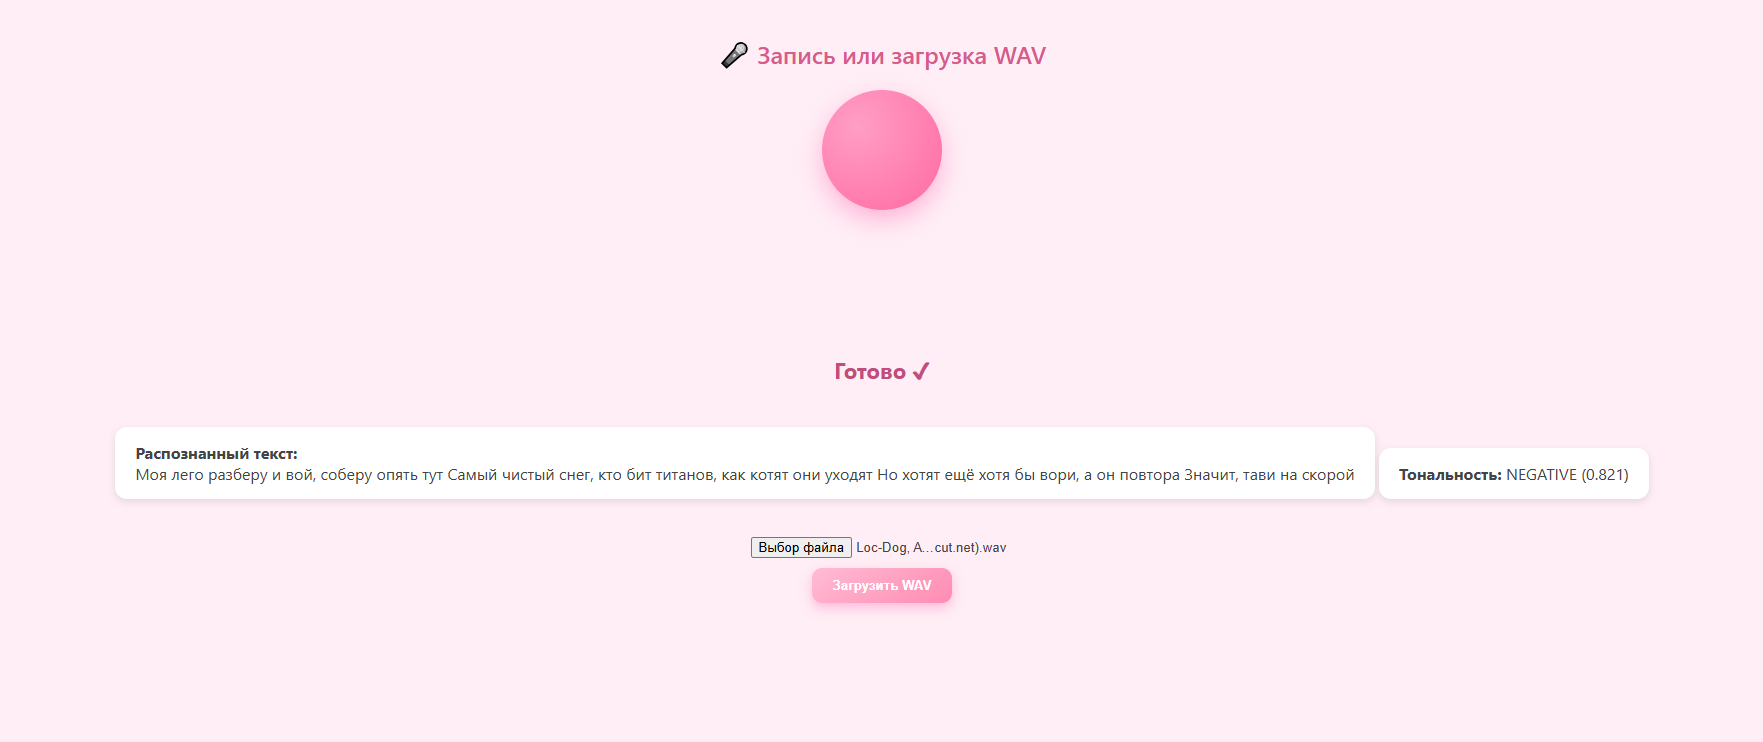

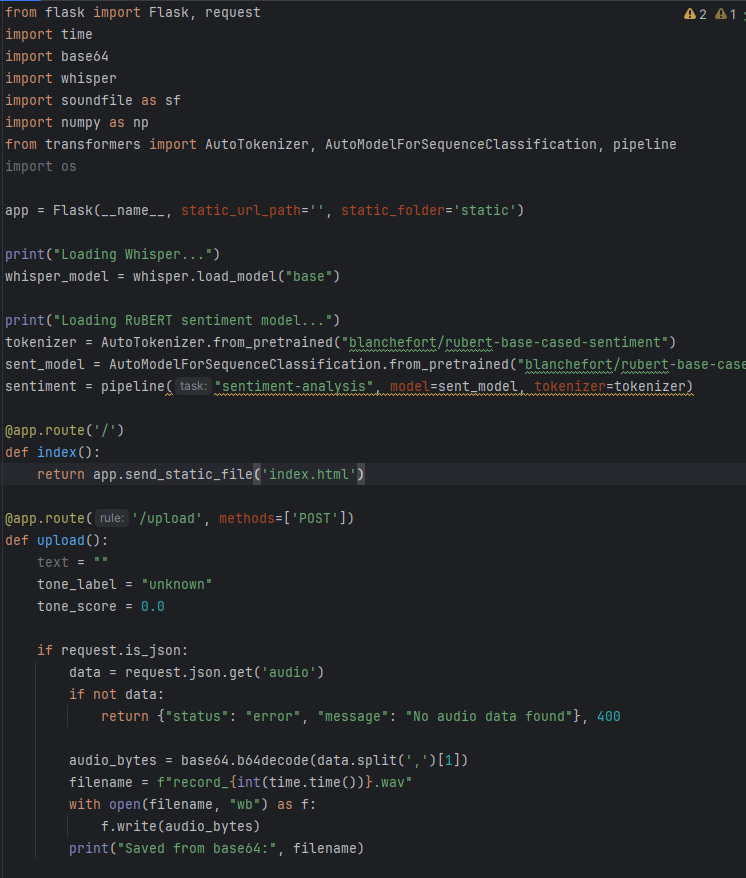

In [ ]:
!pip install sounddevice scipy
!pip install git+https://github.com/openai/whisper.git
!pip install transformers torch


  Cloning https://github.com/openai/whisper.git to /tmp/pip-req-build-mboj3cc7
  Running command git clone --filter=blob:none --quiet https://github.com/openai/whisper.git /tmp/pip-req-build-mboj3cc7
  Resolved https://github.com/openai/whisper.git to commit c0d2f624c09dc18e709e37c2ad90c039a4eb72a2
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for openai-whisper: filename=openai_whisper-20250625-py3-none-any.whl size=803979 sha256=2197bcc79bfc578b81d9376add5306e55250925f3e5101b1ab722b3ef3ebf92d
  Stored in directory: /tmp/pip-ephem-wheel-cache-5zktg_gh/wheels/c3/03/25/5e0ba78bc27a3a089f137c9f1d92fdfce16d06996c071a016c
Successfully built openai-whisper


In [ ]:
from IPython.display import display, Javascript, Audio
from google.colab import output
import base64

def record_audio(seconds=5, filename="recorded.wav"):
    js = f"""
    async function recordAudio() {{
        const stream = await navigator.mediaDevices.getUserMedia({{ audio: true }});
        const mediaRecorder = new MediaRecorder(stream);
        let chunks = [];
        mediaRecorder.ondataavailable = e => chunks.push(e.data);
        mediaRecorder.start();

        await new Promise(resolve => setTimeout(resolve, {seconds} * 1000));
        mediaRecorder.stop();

        await new Promise(resolve => mediaRecorder.onstop = resolve);

        const blob = new Blob(chunks, {{ type: 'audio/wav' }});
        const reader = new FileReader();
        reader.readAsDataURL(blob);
        await new Promise(resolve => reader.onloadend = resolve);
        return reader.result;
    }}
    recordAudio();
    """
    print(f"🎤 Запись {seconds} секунд… Говори!")
    audio_b64 = output.eval_js(js)
    audio_bytes = base64.b64decode(audio_b64.split(',')[1])

    with open(filename, "wb") as f:
        f.write(audio_bytes)

    print(f"✔ Запись завершена, файл сохранен: {filename}")
    return filename

audio_path = record_audio(seconds=5)
display(Audio(audio_path, autoplay=True))


🎤 Запись 5 секунд… Говори!
✔ Запись завершена, файл сохранен: recorded.wav


In [ ]:
import whisper
model = whisper.load_model("small")
result = model.transcribe("/content/LIL_PEEP_-_Star_Shopping_70566050.mp3", language="en")
text = result["text"]
print("🎧 Распознанный текст:", text)

from transformers import AutoTokenizer, AutoModelForSequenceClassification, pipeline
tokenizer = AutoTokenizer.from_pretrained("blanchefort/rubert-base-cased-sentiment")
sent_model = AutoModelForSequenceClassification.from_pretrained("blanchefort/rubert-base-cased-sentiment")
sentiment_pipe = pipeline("sentiment-analysis", model=sent_model, tokenizer=tokenizer)

sentiment = sentiment_pipe(text)
print("❤️ Тональность:", sentiment)

/usr/local/lib/python3.12/dist-packages/whisper/transcribe.py:132: UserWarning: FP16 is not supported on CPU; using FP32 instead
  warnings.warn("FP16 is not supported on CPU; using FP32 instead")


🎧 Распознанный текст:  We're right here, I'll be back in the morning I know that I'm not that important to you What's in me girl is so much more than gorgeous, so much more than perfect Right now I know that I'm not really worth it If you give me time I could work on it Give me some time while I work on it Losing your patience and girl I don't blame you to urge the rotation you waive Look at my face when I fuck on your waist Cause we only have one conversation a week That's why your friend's always hating on me Fuck em know I did this all by myself Matter of fact I ain't never asked no one for help And that's why I don't pick up my phone when I ring None of my exes is over the peak Nobody flexing as much as I be That's why she text me and tell me she love me She know that someday I'll be over the sea Making my money and smoking my weed I think it's funny she open up to me Get comfortable with me once I got it coming I love her she lucky I know that I'm nothing like someone in the famil

Device set to use cpu


❤️ Тональность: [{'label': 'NEGATIVE', 'score': 0.7514399290084839}]


In [ ]:
import whisper
model = whisper.load_model("small")
result = model.transcribe("/content/Skriptonit_-_Polozhenie_51836714 (mp3cut.net).wav", language="ru")
text = result["text"]
print("🎧 Распознанный текст:", text)

from transformers import AutoTokenizer, AutoModelForSequenceClassification, pipeline
tokenizer = AutoTokenizer.from_pretrained("blanchefort/rubert-base-cased-sentiment")
sent_model = AutoModelForSequenceClassification.from_pretrained("blanchefort/rubert-base-cased-sentiment")
sentiment_pipe = pipeline("sentiment-analysis", model=sent_model, tokenizer=tokenizer)

sentiment = sentiment_pipe(text)
print("❤️ Тональность:", sentiment)

/usr/local/lib/python3.12/dist-packages/whisper/transcribe.py:132: UserWarning: FP16 is not supported on CPU; using FP32 instead
  warnings.warn("FP16 is not supported on CPU; using FP32 instead")


🎧 Распознанный текст:  Подавал виду, что бедность чужие здесь и что оно просто и баллов и медов. Даховый время долгов. Пришло время кредитов. Да, а теперь нас каждый день, так день раздень. Мы гупим больше флоскетелек, флоскетелек, и сыграем.


Device set to use cpu


❤️ Тональность: [{'label': 'NEGATIVE', 'score': 0.7514522075653076}]
